In [1]:
import sys
from pathlib import Path

# Add the parent directory to sys.path
parent_path = Path().resolve().parent
if str(parent_path) not in sys.path:
    sys.path.append(str(parent_path))

In [2]:
from pyhgf.model import Network
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az
import seaborn as sns
from jax import config
from models import (
    bayesian_psychophysics,
    cardiac_believing,
    weighted_update,
    sample_cardiac_hgf,
)
import pymc as pm
from scipy.interpolate import interp1d

config.update("jax_enable_x64", True)

plt.rcParams["figure.constrained_layout.use"] = True

In [3]:
participant_id = "sub-0038"
session = 1

In [4]:
# load and filter the data -------------------------------------------------------------
hrd_path = Path.cwd().parent.parent / "data" / "hrd.csv"
hrd_df = pd.read_csv(hrd_path, index_col=0, low_memory=False)

In [5]:
if session == 1:
    hrd_df = hrd_df[
        (
            (hrd_df.cohort == "vmp1")
            & (hrd_df.task == "hrd-session1")
            & (hrd_df.participant_id == participant_id)
            & (~hrd_df.Decision.isnull())
        )
    ]
elif session == 2:
    hrd_df = hrd_df[
        (
            ((hrd_df.cohort == "vmp1") & (hrd_df.task == "hrd-session2"))
            | ((hrd_df.cohort == "vmp2") & (hrd_df.task == "hrd-session1"))
        )
        & (hrd_df.participant_id == participant_id)
        & (~hrd_df.Decision.isnull())
    ]

In [6]:
assert len(hrd_df) > 20

In [7]:
# extract variables of interest ------------------------------------------------------
heart_rate = hrd_df[hrd_df.Modality == "Intero"].listenBPM.to_numpy()
intero_tone_2 = hrd_df[hrd_df.Modality == "Intero"].responseBPM.to_numpy()
intero_decision = (
    hrd_df[hrd_df.Modality == "Intero"].Decision.to_numpy() == "More"
).astype(int)

extero_tone_1 = hrd_df[hrd_df.Modality == "Extero"].listenBPM.to_numpy()
extero_tone_2 = hrd_df[hrd_df.Modality == "Extero"].responseBPM.to_numpy()
extero_decision = (
    hrd_df[hrd_df.Modality == "Extero"].Decision.to_numpy() == "More"
).astype(int)
n = hrd_df.participant_id.nunique()

In [8]:
participant_codes_intero = pd.Categorical(
    hrd_df[hrd_df.Modality == "Intero"].participant_id
).codes

participant_codes_extero = pd.Categorical(
    hrd_df[hrd_df.Modality == "Extero"].participant_id
).codes

In [9]:
input_data_extero = np.array([extero_tone_1, extero_tone_2]).T
input_data_intero = np.array([heart_rate, intero_tone_2]).T

# Standard psychophysics

In [10]:
idata_bayesian_psychophysics, model_bayesian_psychophysics = bayesian_psychophysics(
    heart_rate=heart_rate,
    intero_tone_2=intero_tone_2,
    extero_tone_1=extero_tone_1,
    extero_tone_2=extero_tone_2,
    extero_decision=extero_decision,
    intero_decision=intero_decision,
    n=n,
    participant_codes_extero=participant_codes_extero,
    participant_codes_intero=participant_codes_intero,
)

NUTS[nutpie]: [extero_threshold, extero_slope, intero_threshold, intero_slope]


Output()

In [11]:
pm.compute_log_likelihood(
    idata_bayesian_psychophysics,
    model=model_bayesian_psychophysics,
    var_names=["bin_intero"],
);

Output()

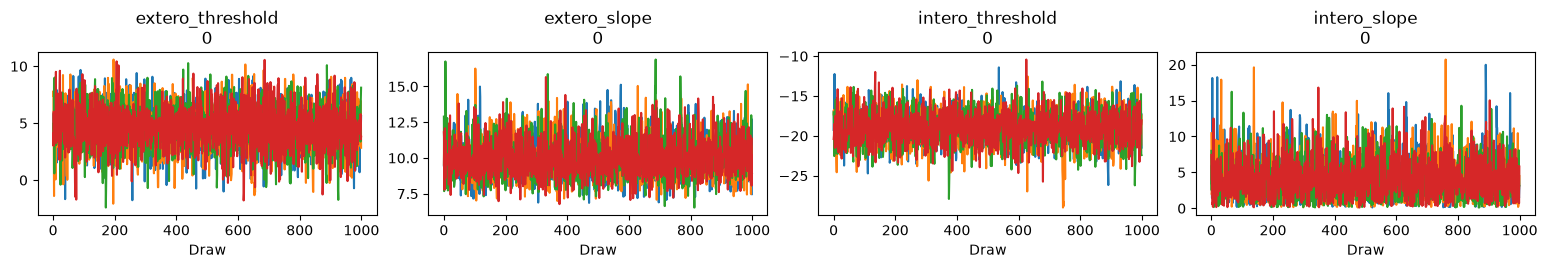

In [12]:
az.plot_trace(
    idata_bayesian_psychophysics,
    var_names=["extero_threshold", "extero_slope", "intero_threshold", "intero_slope"],
);

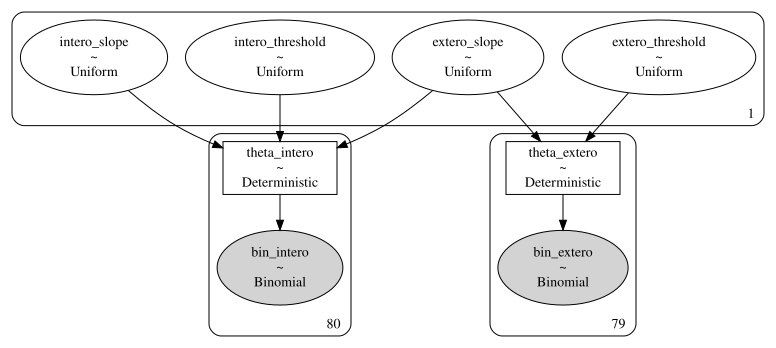

In [13]:
pm.model_to_graphviz(
    model_bayesian_psychophysics,
    save=Path().cwd().parent.parent / "figures" / "Appendix_3_1.pdf",
)

In [14]:
ll_bayesian_psychophysics = (
    idata_bayesian_psychophysics.log_likelihood.bin_intero.mean().values
)

# Cardiac believing

In [15]:
idata_cardiac_believing, model_cardiac_believing = cardiac_believing(
    intero_tone_2=intero_tone_2,
    extero_tone_1=extero_tone_1,
    extero_tone_2=extero_tone_2,
    extero_decision=extero_decision,
    intero_decision=intero_decision,
    n=n,
    participant_codes_extero=participant_codes_extero,
    participant_codes_intero=participant_codes_intero,
)

NUTS[nutpie]: [extero_threshold, extero_slope, intero_mean, intero_std]


Output()

In [16]:
pm.compute_log_likelihood(
    idata_cardiac_believing, model=model_cardiac_believing, var_names=["bin_intero"]
);

Output()

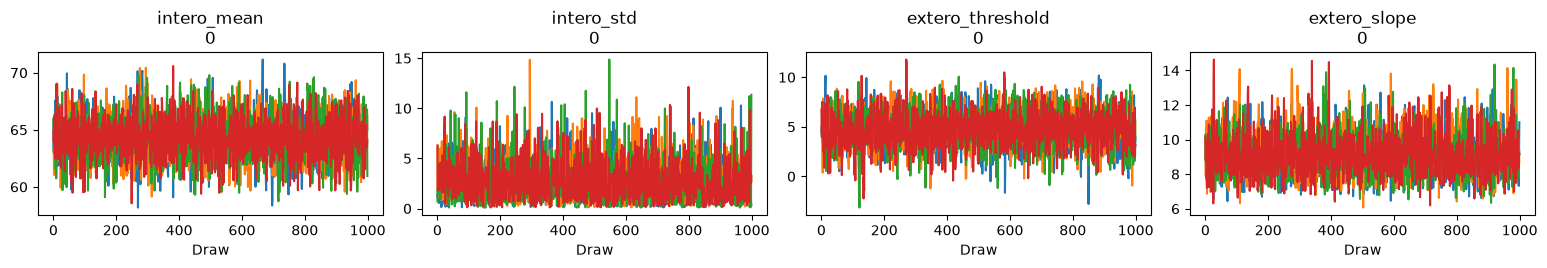

In [17]:
az.plot_trace(
    idata_cardiac_believing,
    var_names=[
        "intero_mean",
        "intero_std",
        "extero_threshold",
        "extero_slope",
    ],
);

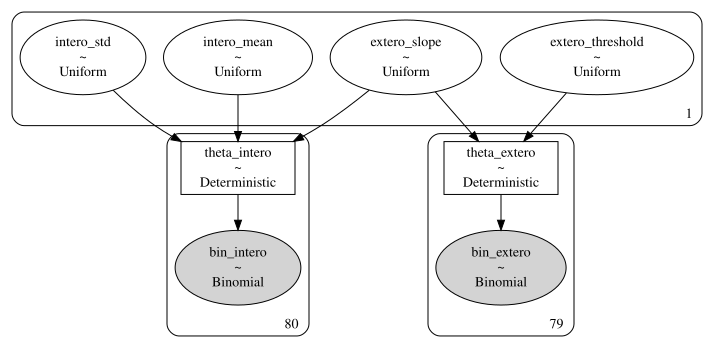

In [18]:
pm.model_to_graphviz(
    model_cardiac_believing,
    save=Path().cwd().parent.parent / "figures" / "Appendix_3_2.pdf",
)

In [19]:
ll_cardiac_believing = idata_cardiac_believing.log_likelihood.bin_intero.mean().values

# Weighted update

In [20]:
idata_weighted_update, model_weighted_update = weighted_update(
    heart_rate=heart_rate,
    intero_tone_2=intero_tone_2,
    extero_tone_1=extero_tone_1,
    extero_tone_2=extero_tone_2,
    extero_decision=extero_decision,
    intero_decision=intero_decision,
    n=n,
    participant_codes_extero=participant_codes_extero,
    participant_codes_intero=participant_codes_intero,
)

NUTS[nutpie]: [mu_extero_prior, sigma_extero_prior, extero_std, omega_extero, mu_cardiac_prior, sigma_cardiac_prior, omega_intero, intero_std]


Output()

In [21]:
pm.compute_log_likelihood(
    idata_weighted_update, model=model_weighted_update, var_names=["bin_intero"]
);

Output()

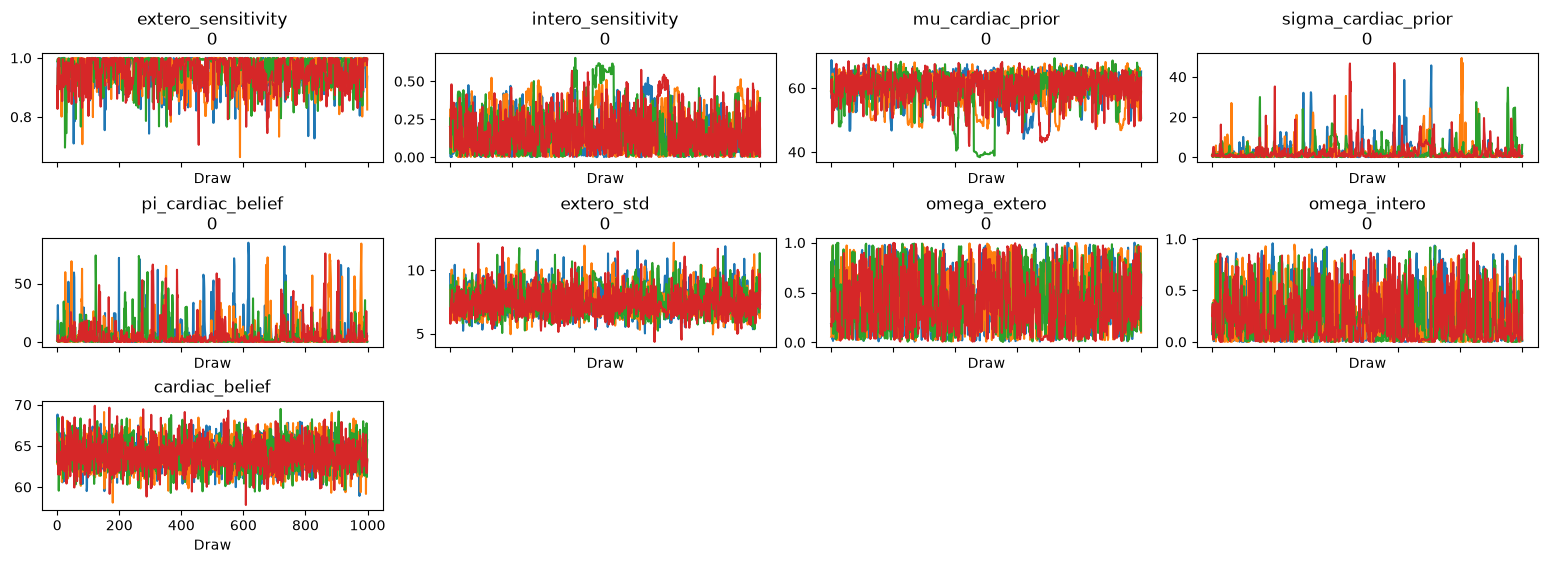

In [22]:
az.plot_trace(
    idata_weighted_update,
    var_names=[
        "extero_sensitivity",
        "intero_sensitivity",
        "mu_cardiac_prior",
        "sigma_cardiac_prior",
        "pi_cardiac_belief",
        "extero_std",
        "omega_extero",
        "omega_intero",
        "cardiac_belief",
    ],
);

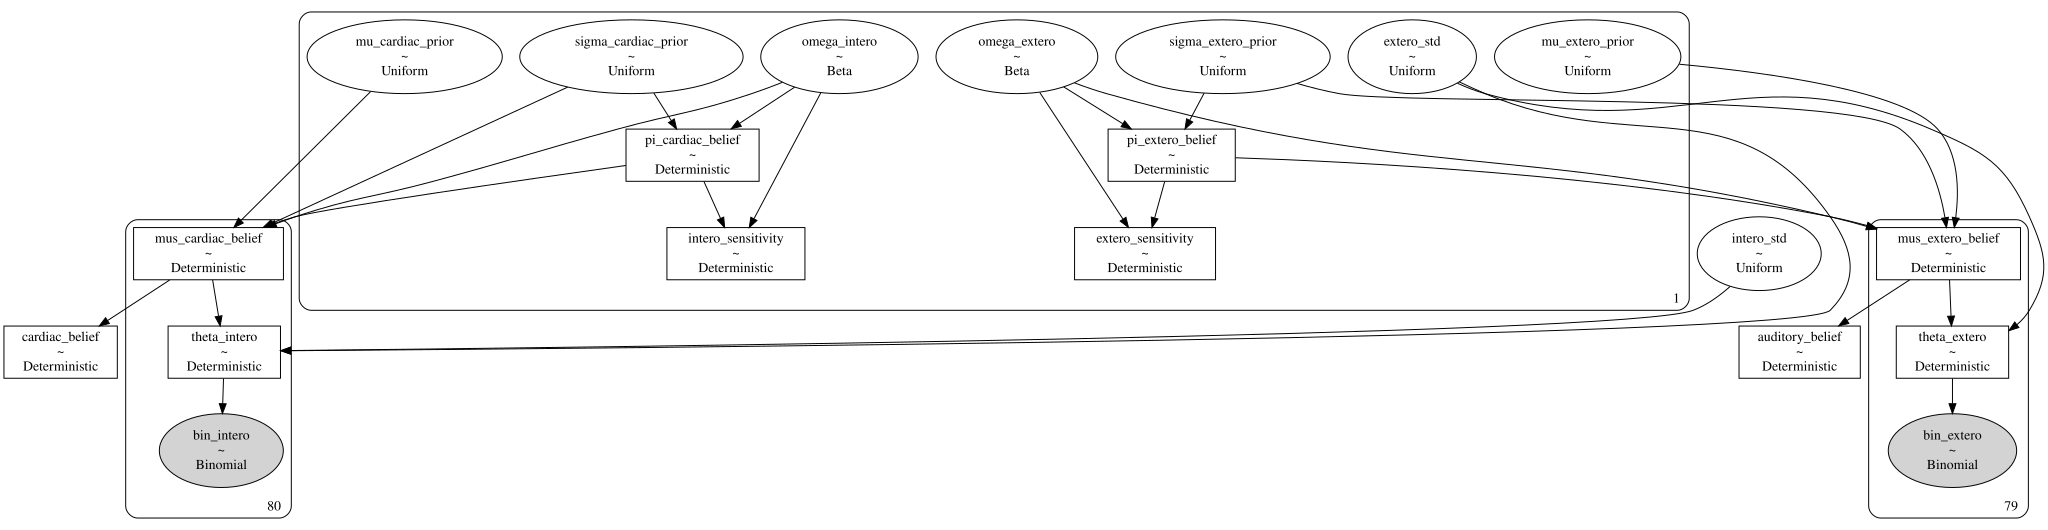

In [23]:
pm.model_to_graphviz(
    model_weighted_update,
    save=Path().cwd().parent.parent / "figures" / "Appendix_3_3.pdf",
)

In [24]:
ll_weighted_update = idata_weighted_update.log_likelihood.bin_intero.mean().values

# Cardiac HGF

In [25]:
idata_cardiac_hgf, model_cardiac_hgf = sample_cardiac_hgf(
    input_data_extero=input_data_extero,
    input_data_intero=input_data_intero,
    extero_decision=extero_decision,
    intero_decision=intero_decision,
    n_cores=4,
)

NUTS[nutpie]: [interoceptive_precision, exteroceptive_precision, interoceptive_tonic_volatility, exteroceptive_tonic_volatility, exteroceptive_mean, interoceptive_mean]


/work/git/ComputationalCardioception/.venv/lib/python3.12/site-packages/pytensor/link/numba/dispatch/basic.py:214: UserWarning: Numba will use object mode to run JAXOp{input_types=(TensorType(float64, shape=()), TensorType(float64, shape=()), TensorType(float64, shape=()), TensorType(float64, shape=()), TensorType(float64, shape=()), TensorType(float64, shape=())), output_types=(TensorType(float64, shape=(162,)),), jax_func=<function wrap_jax.<locals>.decorator.<locals>.wrapper.<locals>.flattened_function at 0x7f66546a3880>}'s perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(
/work/git/ComputationalCardioception/.venv/lib/python3.12/site-packages/pytensor/link/numba/dispatch/basic.py:214: UserWarning: Numba will use object mode to run JAXOp{input_types=(TensorType(float64, shape=()), TensorType(float64, shape=()), TensorType(float64, shape=()), TensorType(float64, shape=()), TensorType(float64, shape=()), TensorType(float64, shape=()), 

Output()

In [26]:
pm.compute_log_likelihood(
    idata_cardiac_hgf, model=model_cardiac_hgf, var_names=["bin_intero"]
);

Output()

/work/git/ComputationalCardioception/.venv/lib/python3.12/site-packages/pytensor/link/numba/dispatch/basic.py:214: UserWarning: Numba will use object mode to run JAXOp{input_types=(TensorType(float64, shape=()), TensorType(float64, shape=()), TensorType(float64, shape=()), TensorType(float64, shape=()), TensorType(float64, shape=()), TensorType(float64, shape=())), output_types=(TensorType(float64, shape=(162,)),), jax_func=<function wrap_jax.<locals>.decorator.<locals>.wrapper.<locals>.flattened_function at 0x7f66546a3880>}'s perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(


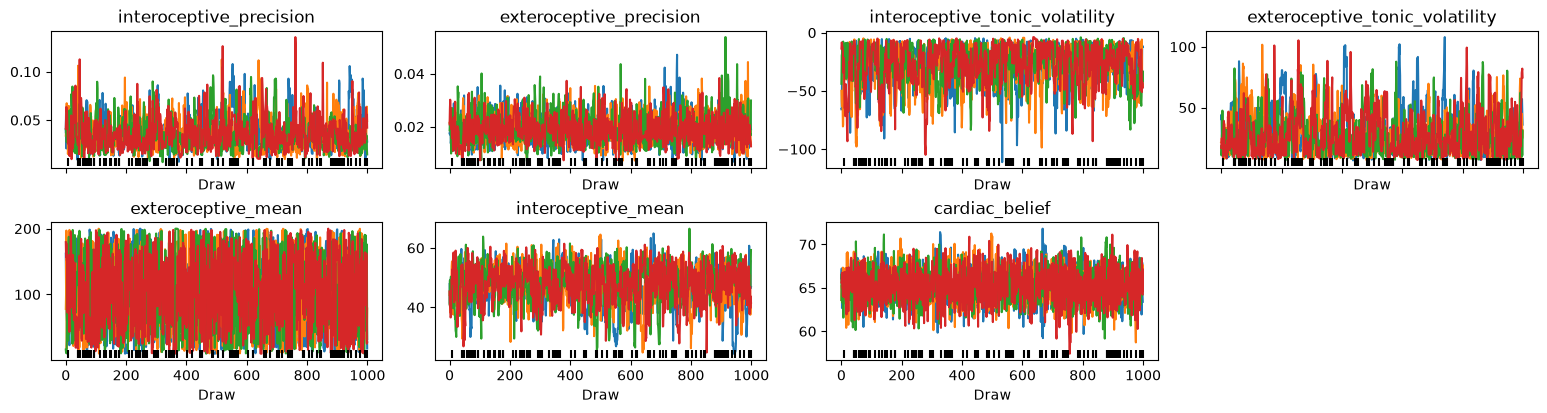

In [27]:
az.plot_trace(
    idata_cardiac_hgf,
    var_names=[
        "interoceptive_precision",
        "exteroceptive_precision",
        "interoceptive_tonic_volatility",
        "exteroceptive_tonic_volatility",
        "exteroceptive_mean",
        "interoceptive_mean",
        "cardiac_belief",
    ],
);

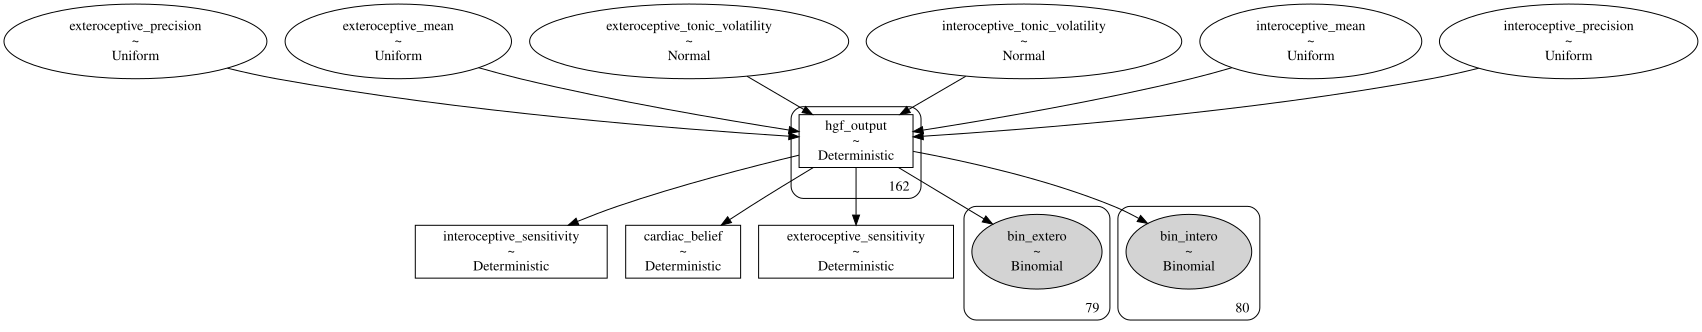

In [28]:
pm.model_to_graphviz(
    model_cardiac_hgf, save=Path().cwd().parent.parent / "figures" / "Appendix_3_4.pdf"
)

In [29]:
ll_cardiac_hgf = idata_cardiac_hgf.log_likelihood.bin_intero.mean().values

# Model comparison

/work/git/ComputationalCardioception/.venv/lib/python3.12/site-packages/arviz_stats/loo/helper_loo.py:1146: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/work/git/ComputationalCardioception/.venv/lib/python3.12/site-packages/arviz_stats/loo/helper_loo.py:1146: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/w

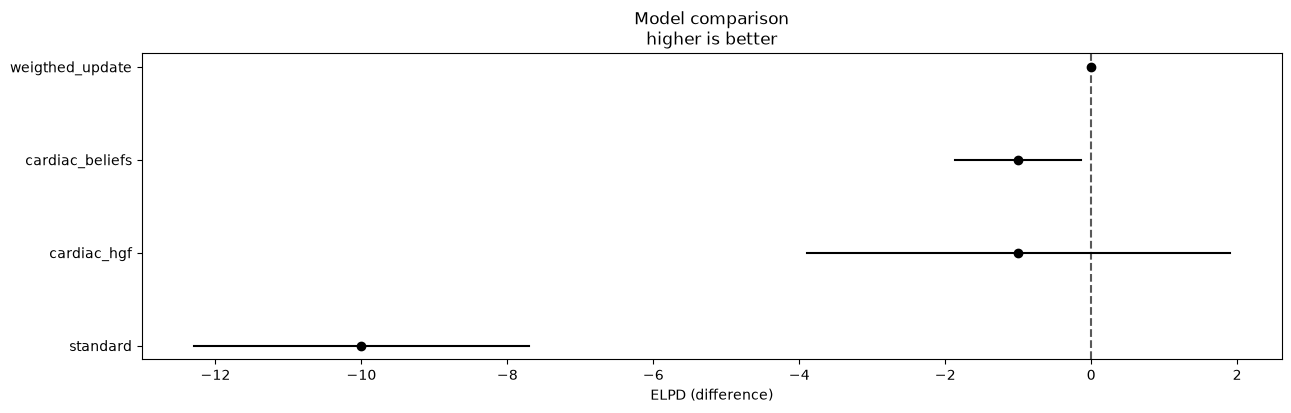

In [30]:
model_compare = az.compare(
    {
        "standard": idata_bayesian_psychophysics,
        "cardiac_beliefs": idata_cardiac_believing,
        "weigthed_update": idata_weighted_update,
        "cardiac_hgf": idata_cardiac_hgf,
    },
)
az.plot_compare(model_compare);

In [31]:
print(f"LL Bayesian Psychophysics: {ll_bayesian_psychophysics}")
print(f"LL Cardiac Believing: {ll_cardiac_believing}")
print(f"LL Weighted Update: {ll_weighted_update}")
print(f"LL Cardiac HGF: {ll_cardiac_hgf}")

LL Bayesian Psychophysics: -0.3618197412126961
LL Cardiac Believing: -0.2519239869696602
LL Weighted Update: -0.24015647009626354
LL Cardiac HGF: -0.2563317744209492


## Plotting models

In [32]:
n_trials_hr = len(heart_rate)
n_trials_ex = len(extero_tone_1)

In [33]:
x_heart_rate = np.arange(0, n_trials_hr)
x_extero = np.arange(0, n_trials_ex)

In [34]:
# Bayesian psychophysics
intero_threshold = (
    az.extract(idata_bayesian_psychophysics, group="posterior")["intero_threshold"]
    .mean(dim="sample")
    .values[0]
)
intero_slope = (
    az.extract(idata_bayesian_psychophysics, group="posterior")["intero_slope"]
    .mean(dim="sample")
    .values[0]
)
extero_threshold = (
    az.extract(idata_bayesian_psychophysics, group="posterior")["extero_threshold"]
    .mean(dim="sample")
    .values[0]
)
extero_slope = (
    az.extract(idata_bayesian_psychophysics, group="posterior")["extero_slope"]
    .mean(dim="sample")
    .values[0]
)

In [35]:
# Cardiac beliefs
beliefs_intero_threshold = (
    az.extract(idata_cardiac_believing, group="posterior")["intero_mean"]
    .mean(dim="sample")
    .values[0]
)
beliefs_intero_slope = (
    az.extract(idata_cardiac_believing, group="posterior")["intero_std"]
    .mean(dim="sample")
    .values[0]
)
beliefs_extero_threshold = (
    az.extract(idata_cardiac_believing, group="posterior")["extero_threshold"]
    .mean(dim="sample")
    .values[0]
)
beliefs_extero_slope = (
    az.extract(idata_cardiac_believing, group="posterior")["extero_slope"]
    .mean(dim="sample")
    .values[0]
)

In [36]:
# Weighted updates
weigthed_intero_std = (
    az.extract(idata_weighted_update, group="posterior")["intero_std"]
    .mean(dim="sample")
    .values
)
weighted_cardiac_beliefs = (
    az.extract(idata_weighted_update, group="posterior")["mus_cardiac_belief"]
    .mean(dim="sample")
    .values
)
weigthed_extero_std = (
    az.extract(idata_weighted_update, group="posterior")["extero_std"]
    .mean(dim="sample")
    .values
)
weighted_auditory_beliefs = (
    az.extract(idata_weighted_update, group="posterior")["mus_extero_belief"]
    .mean(dim="sample")
    .values
)

In [37]:
# Cardiac HGF
interoceptive_precision = (
    az.extract(idata_cardiac_hgf, group="posterior")["interoceptive_precision"]
    .mean(dim="sample")
    .values
)
interoceptive_mean = (
    az.extract(idata_cardiac_hgf, group="posterior")["interoceptive_mean"]
    .mean(dim="sample")
    .values
)
interoceptive_tonic_volatility = (
    az.extract(idata_cardiac_hgf, group="posterior")["interoceptive_tonic_volatility"]
    .mean(dim="sample")
    .values
)

intero_network = (
    Network(volatility_updates="unbounded")
    .add_nodes(
        precision=interoceptive_precision,
        expected_precision=interoceptive_precision,
    )
    .add_nodes(
        value_children=0,
        mean=interoceptive_mean,
        tonic_volatility=interoceptive_tonic_volatility,
    )
)

# set the input data
intero_network.input_data(input_data=heart_rate)
cardiac_hgf_mean = intero_network.node_trajectories[1]["mean"]
cardiac_hgf_interoceptive_precision = intero_network.node_trajectories[0]["precision"]


exteroceptive_precision = (
    az.extract(idata_cardiac_hgf, group="posterior")["exteroceptive_precision"]
    .mean(dim="sample")
    .values
)
exteroceptive_mean = (
    az.extract(idata_cardiac_hgf, group="posterior")["exteroceptive_mean"]
    .mean(dim="sample")
    .values
)
exteroceptive_tonic_volatility = (
    az.extract(idata_cardiac_hgf, group="posterior")["exteroceptive_tonic_volatility"]
    .mean(dim="sample")
    .values
)

extero_network = (
    Network(volatility_updates="unbounded")
    .add_nodes(
        precision=exteroceptive_precision,
        expected_precision=exteroceptive_precision,
    )
    .add_nodes(
        value_children=0,
        mean=exteroceptive_mean,
        tonic_volatility=exteroceptive_tonic_volatility,
    )
)

# set the input data
extero_network.input_data(input_data=extero_tone_1)
cardiac_hgf_extero_mean = extero_network.node_trajectories[1]["mean"]
cardiac_hgf_exteroceptive_precision = extero_network.node_trajectories[0]["precision"]

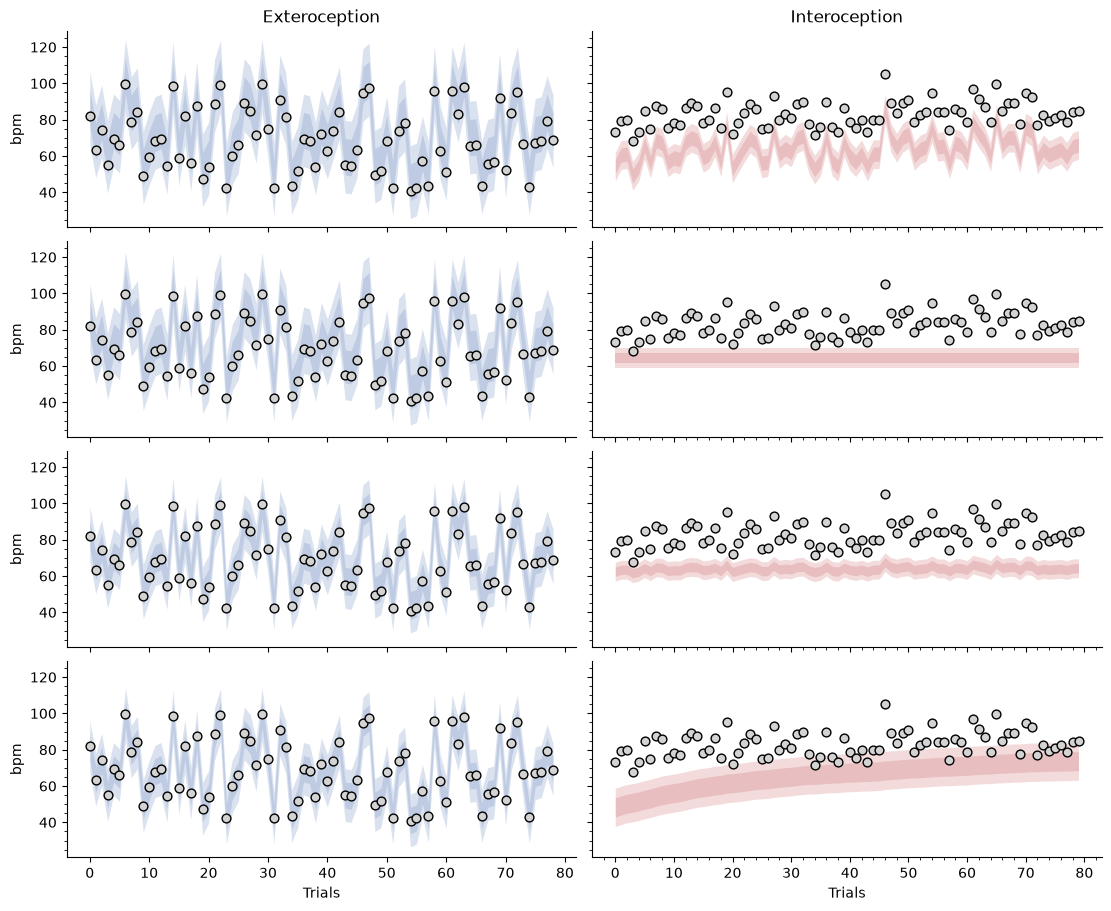

In [38]:
_, axs = plt.subplots(figsize=(11, 9), nrows=4, ncols=2, sharex="col", sharey=True)
plt.minorticks_on()

# Heart rate
# ----------
for i in range(4):
    axs[i, 0].scatter(
        x_extero, extero_tone_1, s=40, color="lightgrey", edgecolor="k", zorder=10
    )
    axs[i, 1].scatter(
        x_heart_rate, heart_rate, s=40, color="lightgrey", edgecolor="k", zorder=10
    )

# Bayesian psychophysics ----------------------------------------
axs[0, 0].fill_between(
    x=x_extero,
    y1=extero_tone_1 + extero_threshold + 2 * extero_slope,
    y2=extero_tone_1 + extero_threshold - 2 * extero_slope,
    color="#4c72b0",
    alpha=0.2,
    linewidth=0,
)
axs[0, 0].fill_between(
    x=x_extero,
    y1=extero_tone_1 + extero_threshold + extero_slope,
    y2=extero_tone_1 + extero_threshold - extero_slope,
    color="#4c72b0",
    alpha=0.2,
    linewidth=0,
)

axs[0, 1].fill_between(
    x=x_heart_rate,
    y1=heart_rate + intero_threshold + 2 * intero_slope,
    y2=heart_rate + intero_threshold - 2 * intero_slope,
    color="#c44e52",
    alpha=0.2,
    linewidth=0,
)
axs[0, 1].fill_between(
    x=x_heart_rate,
    y1=heart_rate + intero_threshold + intero_slope,
    y2=heart_rate + intero_threshold - intero_slope,
    color="#c44e52",
    alpha=0.2,
    linewidth=0,
)

# Cardiac beliefs psychophysics ----------------------------------------
axs[1, 0].fill_between(
    x=x_extero,
    y1=extero_tone_1 + beliefs_extero_threshold + 2 * beliefs_extero_slope,
    y2=extero_tone_1 + beliefs_extero_threshold - 2 * beliefs_extero_slope,
    color="#4c72b0",
    alpha=0.2,
    linewidth=0,
)
axs[1, 0].fill_between(
    x=x_extero,
    y1=extero_tone_1 + beliefs_extero_threshold + beliefs_extero_slope,
    y2=extero_tone_1 + beliefs_extero_threshold - beliefs_extero_slope,
    color="#4c72b0",
    alpha=0.2,
    linewidth=0,
)

axs[1, 1].fill_between(
    x=x_heart_rate,
    y1=beliefs_intero_threshold + 2 * beliefs_intero_slope,
    y2=beliefs_intero_threshold - 2 * beliefs_intero_slope,
    color="#c44e52",
    alpha=0.2,
    linewidth=0,
)
axs[1, 1].fill_between(
    x=x_heart_rate,
    y1=beliefs_intero_threshold + beliefs_intero_slope,
    y2=beliefs_intero_threshold - beliefs_intero_slope,
    color="#c44e52",
    alpha=0.2,
    linewidth=0,
)

# Weighted average ----------------------------------------
axs[2, 1].fill_between(
    x=x_heart_rate,
    y1=weighted_cardiac_beliefs + 2 * weigthed_intero_std,
    y2=weighted_cardiac_beliefs - 2 * weigthed_intero_std,
    color="#c44e52",
    alpha=0.2,
    linewidth=0,
)
axs[2, 1].fill_between(
    x=x_heart_rate,
    y1=weighted_cardiac_beliefs + weigthed_intero_std,
    y2=weighted_cardiac_beliefs - weigthed_intero_std,
    color="#c44e52",
    alpha=0.2,
    linewidth=0,
)

axs[2, 0].fill_between(
    x=x_extero,
    y1=weighted_auditory_beliefs + 2 * weigthed_extero_std,
    y2=weighted_auditory_beliefs - 2 * weigthed_extero_std,
    color="#4c72b0",
    alpha=0.2,
    linewidth=0,
)
axs[2, 0].fill_between(
    x=x_extero,
    y1=weighted_auditory_beliefs + weigthed_extero_std,
    y2=weighted_auditory_beliefs - weigthed_extero_std,
    color="#4c72b0",
    alpha=0.2,
    linewidth=0,
)

# Cardiac HGF ----------------------------------------
axs[3, 0].fill_between(
    x=x_extero,
    y1=cardiac_hgf_extero_mean + 2 * np.sqrt(1 / cardiac_hgf_exteroceptive_precision),
    y2=cardiac_hgf_extero_mean - 2 * np.sqrt(1 / cardiac_hgf_exteroceptive_precision),
    color="#4c72b0",
    alpha=0.2,
    linewidth=0,
)
axs[3, 0].fill_between(
    x=x_extero,
    y1=cardiac_hgf_extero_mean + np.sqrt(1 / cardiac_hgf_exteroceptive_precision),
    y2=cardiac_hgf_extero_mean - np.sqrt(1 / cardiac_hgf_exteroceptive_precision),
    color="#4c72b0",
    alpha=0.2,
    linewidth=0,
)

axs[3, 1].fill_between(
    x=x_heart_rate,
    y1=cardiac_hgf_mean + 2 * np.sqrt(1 / cardiac_hgf_interoceptive_precision),
    y2=cardiac_hgf_mean - 2 * np.sqrt(1 / cardiac_hgf_interoceptive_precision),
    color="#c44e52",
    alpha=0.2,
    linewidth=0,
)
axs[3, 1].fill_between(
    x=x_heart_rate,
    y1=cardiac_hgf_mean + np.sqrt(1 / cardiac_hgf_interoceptive_precision),
    y2=cardiac_hgf_mean - np.sqrt(1 / cardiac_hgf_interoceptive_precision),
    color="#c44e52",
    alpha=0.2,
    linewidth=0,
)


axs[0, 0].set(title="Exteroception", ylabel="bpm")
axs[0, 1].set(title="Interoception")
axs[1, 0].set(ylabel="bpm")
axs[2, 0].set(ylabel="bpm")
axs[3, 0].set(ylabel="bpm", xlabel="Trials")
axs[3, 1].set(xlabel="Trials")
sns.despine()
plt.savefig(Path().cwd().parent.parent / "figures" / "Appendix_1.svg")